In [1]:
# imports
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('external/prop_profiler')))
sys.path.insert(0, os.path.abspath(os.path.join('external/HamDiv')))
import gc
import base64
import re
from IPython.display import HTML, SVG, display

import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from tqdm import tqdm

from external.HamDiv import diversity as hamdiv
from external.prop_profiler.prop_profiler.profiler import profile_molecules
from healer.utils import utils

# FP generator with same parameters as in the HEALER class
fp_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=3, fpSize=2048, includeChirality=True
)


In [2]:
## Helper functions
def unify_result_formats(df: pd.DataFrame, incoming_frmt: str) -> pd.DataFrame:
    '''
        Unify the result format of different methods.

        Args:
            df: DataFrame containing the enumerated compounds.
            incoming_frmt: Format of the incoming DataFrame.
                Options are:
                    - healer
                    - chemprojector
                    - synformer

        Returns:
            pd.DataFrame: DataFrame in Healer's result format. The output will include the following columns:
                - 'Product': SMILES of the enumerated compound.
                - 'num_steps': Number of steps taken to enumerate the compound.
                - 'Similarity_to_query': Similarity of the enumerated compound to the query compound.
                - 'ID': Unique identifier for the enumerated compound as in healer.
                - 'df_id': Identifier for the DataFrame from which the enumeration was generated.
    '''
    if incoming_frmt in ['chemprojector', 'synformer']:
        targets = df['target'].unique()
        output_dfs = []
        for i, target in enumerate(targets):
            target_df = df[df['target'] == target].copy()
            product_fps = [fp_generator.GetFingerprint(Chem.MolFromSmiles(smi)) for smi in target_df['smiles'].values]
            target_fp = fp_generator.GetFingerprint(Chem.MolFromSmiles(target))
            tani_sims = Chem.DataStructs.BulkTanimotoSimilarity(target_fp, product_fps)
            target_df['Similarity_to_query'] = np.round(tani_sims, 2)
            target_df = target_df[['smiles', 'num_steps', 'Similarity_to_query']].sort_values(
                by='Similarity_to_query', ascending=False
            ).reset_index(drop=True)
            query_df = pd.DataFrame({
                'smiles': [target],
                'num_steps': [0],
                'Similarity_to_query': [1.0]
            })
            target_df = pd.concat([query_df, target_df], axis=0).reset_index(drop=True)
            target_df['ID'] = [f'HEAL_{i:06d}' for i in range(len(target_df))]
            target_df = target_df.rename(columns={'smiles': 'Product'})
            target_df['df_id'] = [i] * len(target_df)
            output_dfs.append(target_df)
        return pd.concat(output_dfs, axis=0)[['ID', 'Product', 'num_steps', 'Similarity_to_query', 'df_id']].reset_index(drop=True)
    elif incoming_frmt == 'healer':
        rxn_cols = [col for col in df.columns if col.startswith('Reaction')]
        rxn_cols = df[rxn_cols]
        num_steps = (~pd.isna(rxn_cols)).sum(axis=1)
        df['num_steps'] = num_steps
        targets_df = df[df['ID'] == 'HEAL_000000']
        df_ids = []
        for i in range(len(targets_df)):
            start_idx = targets_df.index[i]
            end_idx = targets_df.index[i + 1] if i + 1 < len(targets_df) else len(df)
            df_ids.extend([i] * (end_idx - start_idx))
        df['df_id'] = df_ids
        return df[['ID', 'Product', 'num_steps', 'Similarity_to_query', 'df_id']].reset_index(drop=True)
    else:
        raise ValueError(f"Unknown incoming format: {incoming_frmt}. Supported formats are: 'chemprojector', 'synformer', 'healer'.")

def get_top_n_subset(data: pd.DataFrame, n=100) -> pd.DataFrame:
    '''
        Get the top n enumerations from the DataFrame, including the query molecules. 
        This will drop duplicates in each query enumeration.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to retrieve. Default is 100.

        Returns:
            pd.DataFrame: A DataFrame containing the top n enumerations plus the query molecules.
                The output will include the following columns:
                    - 'ID': Unique identifier for the enumerated compound as in healer.
                    - 'Product': SMILES of the enumerated compound.
                    - 'num_steps': Number of steps taken to enumerate the compound.
                    - 'Similarity_to_query': Similarity of the enumerated compound to the query compound.
                    - 'df_id': Identifier for the DataFrame from which the enumeration was generated.
    '''
    return data.drop_duplicates(subset=['df_id', 'Product']).groupby('df_id').head(n+1).reset_index(drop=True)

def calc_ser(data: pd.DataFrame) -> float:
    '''
        Calculate the Successful Enumeration Rate (SER) for the enumerated compounds.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.

        Returns:
            float: The Successful Enumeration Rate (SER) calculated as the ratio of 
                successful enumerations to total enumerations.
    '''
    successful_enums = len(data[data['ID'] == 'HEAL_000001'])
    total_enums = len(data[data['ID'] == 'HEAL_000000'])
    return successful_enums / total_enums
    
def calc_rr(data: pd.DataFrame) -> float:
    '''
        Calculate the Reconstruction Rate (RR) for the enumerated compounds.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.

        Returns:
            float: The Reconstruction Rate (RR) calculated as the ratio of 
                successfully reconstructed enumerations to total enumerations.
    '''
    enums = data[data['ID'] == 'HEAL_000001']
    successful_reconstructions = len(enums[enums['Similarity_to_query'] == 1.0])
    total_enums = len(data[data['ID'] == 'HEAL_000000'])
    return successful_reconstructions / total_enums

def calc_top_n_average_sims(data: pd.DataFrame, n=100) -> np.ndarray:
    '''
        Calculate the average similarity of the top n enumerations to the query.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            np.ndarray: An array containing the average similarity of the top n 
                enumerations to the query for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    avg_sims = top_n_data.groupby('df_id')['Similarity_to_query'].apply(lambda x: x.iloc[1:].mean() if len(x) > 1 else np.nan)
    return avg_sims.to_numpy()

def calc_top_n_average_diversities(data: pd.DataFrame, n=100) -> np.ndarray:
    '''
        Calculate the average diversity of the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            np.ndarray: An array containing the average diversity of the top n 
                enumerations for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    avg_divs = top_n_data.groupby('df_id')['Product'].apply(
        lambda x: get_diversity_score(x.iloc[1:].tolist(), mode='HamDiv') if len(x) > 1 else 0
    )
    return avg_divs.to_numpy()

def calc_top_n_average_num_steps(data: pd.DataFrame, n=100) -> np.ndarray:
    '''
        Calculate the average number of reaction steps for the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            np.ndarray: An array containing the average number of reaction steps 
                for the top n enumerations for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    avg_steps = top_n_data.groupby('df_id')['num_steps'].apply(lambda x: x.iloc[1:].mean() if len(x) > 1 else np.nan)
    return avg_steps.to_numpy()

def run_profiler(data: pd.DataFrame, device='cuda', verbose=False) -> pd.DataFrame:
    '''
        Run the molecule profiler on the given DataFrame along with the SA score calculation.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            device (str): The device to run the profiler on. Default is 'cuda'.
            verbose (bool): Whether to print verbose output. Default is False.

        Returns:
            pd.DataFrame: A DataFrame containing the profiling results.
    '''
    data['SA_score'] = data['Product'].apply(lambda x: utils.get_sascore(x))
    prop_data = profile_molecules(data['Product'].to_list(), device=device, verbose=verbose)
    prop_data = prop_data.rename(columns={'smiles': 'Product'})
    data = pd.merge(
        data, prop_data, how='left', on='Product'
    )
    return data

def calc_top_n_max_qed_improvements(data: pd.DataFrame, n=100) -> np.ndarray:
    '''
        Calculate the max QED improvements of the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            np.ndarray: An array containing the max QED improvements of the 
                top n enumerations for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    avg_qed_improvements = top_n_data.groupby('df_id')['qed'].apply(
        lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
    )
    return avg_qed_improvements.to_numpy()

def calc_top_n_max_cns_mpo_improvements(data: pd.DataFrame, n=100) -> np.ndarray:
    '''
        Calculate the max CNS-MPO improvements of the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            np.ndarray: An array containing the max CNS-MPO improvements of the 
                top n enumerations for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    avg_cns_mpo_improvements = top_n_data.groupby('df_id')['cns_mpo_score'].apply(
        lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
    )
    return avg_cns_mpo_improvements.to_numpy()

def calc_top_n_max_stoplight_improvements(data: pd.DataFrame, n=100) -> np.ndarray:
    '''
        Calculate the max stoplight score improvements of the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            np.ndarray: An array containing the max stoplight score improvements of the 
                top n enumerations for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    avg_stoplight_improvements = top_n_data.groupby('df_id')['stoplight_score'].apply(
        lambda x: np.nanmin(x - x.iloc[0]) if len(x) > 1 else 0
    )
    return avg_stoplight_improvements.to_numpy()

def calc_top_n_stoplight_color_changes(data: pd.DataFrame, n=100) -> dict:
    '''
        Calculate the stoplight color changes for the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            dict: A dictionary containing the stoplight color changes for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    stoplight_changes = {
        'red2green': [], 'red2yellow': [], 'red2red': [],
        'yellow2green': [], 'yellow2yellow': [], 'yellow2red': [],
        'green2green': [], 'green2yellow': [], 'green2red': []
    }
    for df_id, group in top_n_data.groupby('df_id'):
        stoplight_colors = group['stoplight_color'].values
        query_color = stoplight_colors[0]
        n = len(stoplight_colors)
        if query_color == 'red':
            stoplight_changes['red2green'].append(
                len([1 for x in stoplight_colors[1:] if x == 'green']) / (n - 1) if n > 1 else np.nan
            )
            stoplight_changes['red2yellow'].append(
                len([1 for x in stoplight_colors[1:] if x == 'yellow']) / (n - 1) if n > 1 else np.nan
            )
            stoplight_changes['red2red'].append(
                len([1 for x in stoplight_colors[1:] if x == 'red']) / (n - 1) if n > 1 else np.nan
            )
        elif query_color == 'yellow':
            stoplight_changes['yellow2green'].append(
                len([1 for x in stoplight_colors[1:] if x == 'green']) / (n - 1) if n > 1 else np.nan
            )
            stoplight_changes['yellow2yellow'].append(
                len([1 for x in stoplight_colors[1:] if x == 'yellow']) / (n - 1) if n > 1 else np.nan
            )
            stoplight_changes['yellow2red'].append(
                len([1 for x in stoplight_colors[1:] if x == 'red']) / (n - 1) if n > 1 else np.nan
            )
        elif query_color == 'green':
            stoplight_changes['green2green'].append(
                len([1 for x in stoplight_colors[1:] if x == 'green']) / (n - 1) if n > 1 else np.nan
            )
            stoplight_changes['green2yellow'].append(
                len([1 for x in stoplight_colors[1:] if x == 'yellow']) / (n - 1) if n > 1 else np.nan
            )
            stoplight_changes['green2red'].append(
                len([1 for x in stoplight_colors[1:] if x == 'red']) / (n - 1) if n > 1 else np.nan
            )

    for key in stoplight_changes:
        stoplight_changes[key] = np.nanmean(stoplight_changes[key])
    return stoplight_changes

def get_summary_stats(data: pd.DataFrame, n=[1, 5, 10, 25]) -> dict:
    '''
        Get summary statistics for the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (list): A list of integers representing the number of top enumerations to consider.
                Default is [1, 5, 10, 25].

        Returns:
            dict: A dictionary containing the summary statistics for each n in the list.
                The keys:
                    - 'Top-n Average Similarity': Average similarity of the top n enumerations to the query
                    - 'Top-n Average Diversity': Average diversity of the top n enumerations
                    - 'Top-n Average Number of Steps': Average number of reaction steps for the top n enumerations
    '''
    summary_stats = {}
    for top_n in tqdm(n, desc='Calculating summary statistics', total=len(n)):
        summary_stats[f'Top-{top_n} Average Similarity'] = np.nanmean(calc_top_n_average_sims(data, n=top_n))
        summary_stats[f'Top-{top_n} Average Diversity'] = np.nanmean(calc_top_n_average_diversities(data, n=top_n))
        summary_stats[f'Top-{top_n} Average Number of Steps'] = np.nanmean(calc_top_n_average_num_steps(data, n=top_n))

    return summary_stats
    

def get_top_n_optimization_stats(data: pd.DataFrame, n=100) -> dict:
    '''
        Get optimization statistics for the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            dict: A dictionary containing the QED, Stoplight and CNS-MPO statistics for each n in the list.
                The keys:
                    - 'Top-n Average QED': Average QED of the top n enumerations
                    - 'Top-n Average Stoplight': Average Stoplight of the top n enumerations
                    - 'Top-n Average CNS-MPO': Average CNS-MPO of the top n enumerations
                    - All stoplight color changes for the top n enumerations
    '''
    optimization_stats = {}
    optimization_stats[f'Top-{n} Average of Max QED Improvements'] = np.nanmean(calc_top_n_max_qed_improvements(data, n=n))
    optimization_stats[f'Top-{n} Average of Max Stoplight Improvements'] = np.nanmean(calc_top_n_max_stoplight_improvements(data, n=n))
    optimization_stats[f'Top-{n} Average of Max CNS-MPO Improvements'] = np.nanmean(calc_top_n_max_cns_mpo_improvements(data, n=n))
    optimization_stats.update(calc_top_n_stoplight_color_changes(data, n=n))

    return optimization_stats

def get_diversity_score(smiles, mode='HamDiv'):
    '''
        Calculate the diversity score of a list of SMILES strings.

        Args:
            smiles (list): A list of SMILES strings.
            mode (str): The method to calculate diversity. Options are
                HamDiv, FG, RS, BM, Richness, IntDiv, SumDiv, Diam, SumDiam,
                Bot, SumBot, DPP, and NCircles-0.x.

        Returns:
            float: The diversity score.
    '''
    if mode in ['FG', 'RS', 'BM', 'Richness']:
        return hamdiv.diversity_all(smiles, mode=mode)
    
    dists = get_pdist_matrix(smiles)
    if mode == 'HamDiv':
        n = len(smiles)
        comp_method = 'exact_dp' if n <= 5 else 'local_search' if n <= 20 else 'greedy_tsp'
        return hamdiv.HamDiv(smiles, dists=dists, method=comp_method)
    
    return hamdiv.diversity_all(smiles, dists=dists, mode=mode)

def get_pdist_matrix(smiles):
    '''
        Calculate the pairwise distance matrix for a list of SMILES strings.

        Args:
            smiles (list): A list of SMILES strings.

        Returns:
            np.ndarray: The pairwise distance matrix.
    '''
    fps = [fp_generator.GetFingerprint(Chem.MolFromSmiles(smi)) for smi in smiles]
    sims = np.zeros((len(smiles), len(smiles)))
    for i in range(len(smiles)):
        sims[i] = Chem.DataStructs.BulkTanimotoSimilarity(fps[i], fps)
    return 1 - sims

def min_max_normalize(arr):
    '''
        Min-max normalization of an array.

        Args:
            arr (np.ndarray): The array to be normalized.

        Returns:
            np.ndarray: The normalized array.
    '''
    arr = np.array(arr)
    arr_min = np.min(arr)
    arr_max = np.max(arr)
    return (arr - arr_min) / (arr_max - arr_min)


# Enumerations Results


In [4]:
## Configuration
sim_cutoff = 0.3
top_n_partitions = [1, 5, 10, 25, 50, 100]
overwrite_subset = False

healer_dtypes = {
    'ID': str, 'Product': str, 
    'BB1': str, 'BB2': str, 'BB3': str, 'BB4': str,
    'Reaction1_name': str, 'Reaction2_name': str, 'Reaction3_name': str,
    'URL1': str, 'URL2': str, 'URL3': str, 'URL4': str,
    'Similarity_to_query': float
}

## Load benchmark results and calculate summary statistics
# HEALER Enamine 1k random enumerations
file_path = 'benchmark/results/healer/enamine_1k_random_enums.csv'
enums = pd.read_csv(file_path, dtype=healer_dtypes)
unified_enums = unify_result_formats(enums, incoming_frmt='healer')
unified_enums = unified_enums[unified_enums['Similarity_to_query'] > sim_cutoff].reset_index(drop=True)
subset_file_path = file_path.replace('.csv', f'_subset{top_n_partitions[-1]}.csv')
if not os.path.exists(subset_file_path) or overwrite_subset:
    healer_enamine_subset = get_top_n_subset(unified_enums, n=top_n_partitions[-1])
    healer_enamine_subset = run_profiler(healer_enamine_subset, device='cuda', verbose=True)
    healer_enamine_subset.to_csv(subset_file_path, index=False)
else:
    healer_enamine_subset = pd.read_csv(subset_file_path)
healer_enamine_summary_stats = {'SER': calc_ser(unified_enums), 'RR': calc_rr(unified_enums)}
healer_enamine_summary_stats.update(get_summary_stats(healer_enamine_subset, n=top_n_partitions))
healer_enamine_opt_stats = get_top_n_optimization_stats(healer_enamine_subset, n=top_n_partitions[-1])

# HEALER ChemBL 1k random enumerations
file_path = 'benchmark/results/healer/chembl_1k_random_enums.csv'
enums = pd.read_csv(file_path, dtype=healer_dtypes)
unified_enums = unify_result_formats(enums, incoming_frmt='healer')
unified_enums = unified_enums[unified_enums['Similarity_to_query'] > sim_cutoff].reset_index(drop=True)
subset_file_path = file_path.replace('.csv', f'_subset{top_n_partitions[-1]}.csv')
if not os.path.exists(subset_file_path) or overwrite_subset:
    healer_chembl_subset = get_top_n_subset(unified_enums, n=top_n_partitions[-1])
    healer_chembl_subset = run_profiler(healer_chembl_subset, device='cuda', verbose=True)
    healer_chembl_subset.to_csv(subset_file_path, index=False)
else:
    healer_chembl_subset = pd.read_csv(subset_file_path)
healer_chembl_summary_stats = {'SER': calc_ser(unified_enums), 'RR': calc_rr(unified_enums)}
healer_chembl_summary_stats.update(get_summary_stats(healer_chembl_subset, n=top_n_partitions))
healer_chembl_opt_stats = get_top_n_optimization_stats(healer_chembl_subset, n=top_n_partitions[-1])

# HEALER ASKCOS unsynthesizable 1k random enumerations
file_path = 'benchmark/results/healer/askcos_unsynthesizable_1k_random_enums.csv'
enums = pd.read_csv(file_path, dtype=healer_dtypes)
unified_enums = unify_result_formats(enums, incoming_frmt='healer')
unified_enums = unified_enums[unified_enums['Similarity_to_query'] > sim_cutoff].reset_index(drop=True)
subset_file_path = file_path.replace('.csv', f'_subset{top_n_partitions[-1]}.csv')
if not os.path.exists(subset_file_path) or overwrite_subset:
    healer_askcos_subset = get_top_n_subset(unified_enums, n=top_n_partitions[-1])
    healer_askcos_subset = run_profiler(healer_askcos_subset, device='cuda', verbose=True)
    healer_askcos_subset.to_csv(subset_file_path, index=False)
else:
    healer_askcos_subset = pd.read_csv(subset_file_path)
healer_askcos_summary_stats = {'SER': calc_ser(unified_enums), 'RR': calc_rr(unified_enums)}
healer_askcos_summary_stats.update(get_summary_stats(healer_askcos_subset, n=top_n_partitions))
healer_askcos_opt_stats = get_top_n_optimization_stats(healer_askcos_subset, n=top_n_partitions[-1])

# ChemProjector Enamine 1k random enumerations
file_path = 'benchmark/results/chemprojector/enamine_1k_random_enums.csv'
enums = pd.read_csv(file_path)
unified_enums = unify_result_formats(enums, incoming_frmt='chemprojector')
unified_enums = unified_enums[unified_enums['Similarity_to_query'] > sim_cutoff].reset_index(drop=True)
subset_file_path = file_path.replace('.csv', f'_subset{top_n_partitions[-1]}.csv')
if not os.path.exists(subset_file_path) or overwrite_subset:
    chemprojector_enamine_subset = get_top_n_subset(unified_enums, n=top_n_partitions[-1])
    chemprojector_enamine_subset = run_profiler(chemprojector_enamine_subset, device='cuda', verbose=True)
    chemprojector_enamine_subset.to_csv(subset_file_path, index=False)
else:
    chemprojector_enamine_subset = pd.read_csv(subset_file_path)
chemprojector_enamine_summary_stats = {'SER': calc_ser(unified_enums), 'RR': calc_rr(unified_enums)}
chemprojector_enamine_summary_stats.update(get_summary_stats(chemprojector_enamine_subset, n=top_n_partitions))
chemprojector_enamine_opt_stats = get_top_n_optimization_stats(chemprojector_enamine_subset, n=top_n_partitions[-1])

# ChemProjector ChemBL 1k random enumerations
file_path = 'benchmark/results/chemprojector/chembl_1k_random_enums.csv'
enums = pd.read_csv(file_path)
unified_enums = unify_result_formats(enums, incoming_frmt='chemprojector')
unified_enums = unified_enums[unified_enums['Similarity_to_query'] > sim_cutoff].reset_index(drop=True)
subset_file_path = file_path.replace('.csv', f'_subset{top_n_partitions[-1]}.csv')
if not os.path.exists(subset_file_path) or overwrite_subset:
    chemprojector_chembl_subset = get_top_n_subset(unified_enums, n=top_n_partitions[-1])
    chemprojector_chembl_subset = run_profiler(chemprojector_chembl_subset, device='cuda', verbose=True)
    chemprojector_chembl_subset.to_csv(subset_file_path, index=False)
else:
    chemprojector_chembl_subset = pd.read_csv(subset_file_path)
chemprojector_chembl_summary_stats = {'SER': calc_ser(unified_enums), 'RR': calc_rr(unified_enums)}
chemprojector_chembl_summary_stats.update(get_summary_stats(chemprojector_chembl_subset, n=top_n_partitions))
chemprojector_chembl_opt_stats = get_top_n_optimization_stats(chemprojector_chembl_subset, n=top_n_partitions[-1])

# ChemProjector ASKCOS unsynthesizable 1k random enumerations
file_path = 'benchmark/results/chemprojector/askcos_unsynthesizable_1k_random_enums.csv'
enums = pd.read_csv(file_path)
unified_enums = unify_result_formats(enums, incoming_frmt='chemprojector')
unified_enums = unified_enums[unified_enums['Similarity_to_query'] > sim_cutoff].reset_index(drop=True)
subset_file_path = file_path.replace('.csv', f'_subset{top_n_partitions[-1]}.csv')
if not os.path.exists(subset_file_path) or overwrite_subset:
    chemprojector_askcos_subset = get_top_n_subset(unified_enums, n=top_n_partitions[-1])
    chemprojector_askcos_subset = run_profiler(chemprojector_askcos_subset, device='cuda', verbose=True)
    chemprojector_askcos_subset.to_csv(subset_file_path, index=False)
else:
    chemprojector_askcos_subset = pd.read_csv(subset_file_path)
chemprojector_askcos_summary_stats = {'SER': calc_ser(unified_enums), 'RR': calc_rr(unified_enums)}
chemprojector_askcos_summary_stats.update(get_summary_stats(chemprojector_askcos_subset, n=top_n_partitions))
chemprojector_askcos_opt_stats = get_top_n_optimization_stats(chemprojector_askcos_subset, n=top_n_partitions[-1])

# Synformer Enamine 1k random enumerations
file_path = 'benchmark/results/synformer/enamine_1k_random_enums.csv'
enums = pd.read_csv(file_path)
unified_enums = unify_result_formats(enums, incoming_frmt='synformer')
unified_enums = unified_enums[unified_enums['Similarity_to_query'] > sim_cutoff].reset_index(drop=True)
subset_file_path = file_path.replace('.csv', f'_subset{top_n_partitions[-1]}.csv')
if not os.path.exists(subset_file_path) or overwrite_subset:
    synformer_enamine_subset = get_top_n_subset(unified_enums, n=top_n_partitions[-1])
    synformer_enamine_subset = run_profiler(synformer_enamine_subset, device='cuda', verbose=True)
    synformer_enamine_subset.to_csv(subset_file_path, index=False)
else:
    synformer_enamine_subset = pd.read_csv(subset_file_path)
synformer_enamine_summary_stats = {'SER': calc_ser(unified_enums), 'RR': calc_rr(unified_enums)}
synformer_enamine_summary_stats.update(get_summary_stats(synformer_enamine_subset, n=top_n_partitions))
synformer_enamine_opt_stats = get_top_n_optimization_stats(synformer_enamine_subset, n=top_n_partitions[-1])

# Synformer ChemBL 1k random enumerations
file_path = 'benchmark/results/synformer/chembl_1k_random_enums.csv'
enums = pd.read_csv(file_path)
unified_enums = unify_result_formats(enums, incoming_frmt='synformer')
unified_enums = unified_enums[unified_enums['Similarity_to_query'] > sim_cutoff].reset_index(drop=True)
subset_file_path = file_path.replace('.csv', f'_subset{top_n_partitions[-1]}.csv')
if not os.path.exists(subset_file_path) or overwrite_subset:
    synformer_chembl_subset = get_top_n_subset(unified_enums, n=top_n_partitions[-1])
    synformer_chembl_subset = run_profiler(synformer_chembl_subset, device='cuda', verbose=True)
    synformer_chembl_subset.to_csv(subset_file_path, index=False)
else:
    synformer_chembl_subset = pd.read_csv(subset_file_path)
synformer_chembl_summary_stats = {'SER': calc_ser(unified_enums), 'RR': calc_rr(unified_enums)}
synformer_chembl_summary_stats.update(get_summary_stats(synformer_chembl_subset, n=top_n_partitions))
synformer_chembl_opt_stats = get_top_n_optimization_stats(synformer_chembl_subset, n=top_n_partitions[-1])

# Synformer ASKCOS unsynthesizable 1k random enumerations
file_path = 'benchmark/results/synformer/askcos_unsynthesizable_1k_random_enums.csv'
enums = pd.read_csv(file_path)
unified_enums = unify_result_formats(enums, incoming_frmt='synformer')
unified_enums = unified_enums[unified_enums['Similarity_to_query'] > sim_cutoff].reset_index(drop=True)
subset_file_path = file_path.replace('.csv', f'_subset{top_n_partitions[-1]}.csv')
if not os.path.exists(subset_file_path) or overwrite_subset:
    synformer_askcos_subset = get_top_n_subset(unified_enums, n=top_n_partitions[-1])
    synformer_askcos_subset = run_profiler(synformer_askcos_subset, device='cuda', verbose=True)
    synformer_askcos_subset.to_csv(subset_file_path, index=False)
else:
    synformer_askcos_subset = pd.read_csv(subset_file_path)
synformer_askcos_summary_stats = {'SER': calc_ser(unified_enums), 'RR': calc_rr(unified_enums)}
synformer_askcos_summary_stats.update(get_summary_stats(synformer_askcos_subset, n=top_n_partitions))
synformer_askcos_opt_stats = get_top_n_optimization_stats(synformer_askcos_subset, n=top_n_partitions[-1])


Calculating summary statistics: 100%|██████████| 6/6 [00:31<00:00,  5.29s/it]
/tmp/ipykernel_29528/2729424437.py:196: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
/tmp/ipykernel_29528/2729424437.py:232: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmin(x - x.iloc[0]) if len(x) > 1 else 0
/tmp/ipykernel_29528/2729424437.py:214: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
Calculating summary statistics: 100%|██████████| 6/6 [00:14<00:00,  2.46s/it]
/tmp/ipykernel_29528/2729424437.py:196: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
/tmp/ipykernel_29528/2729424437.py:232: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmin(x - x.iloc[0]) if len(x) > 1 else 0
/tmp/ipykernel_29528/2729424437.py:214: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
Calculatin

# Comparison of Enumeration Statistics by Dataset and by Method


In [5]:
# multi-label table from dictionaries
def highlight_extremes(row, min_rows):
    styles = pd.Series("", index=row.index)
    prefer_min = row.name in min_rows

    # iterate over each Dataset group
    for ds in row.index.get_level_values(0).unique():
        sub = row[ds]  # Series indexed by Method
        target_value = sub.min() if prefer_min else sub.max()
        # bold all cells equal to the target
        mask = sub == target_value
        for method in sub.index:
            if mask.loc[method]:
                styles[(ds, method)] = "font-weight: bold"

    return styles

table_styles = [
    {# index names
        'selector': 'th.index_name:(.col_heading)',
        'props': 'font-style: italic; color: #323232; font-weight: bold; font-size: 12px; text-align: right;'
    },
    {# row index name
        'selector': 'th.index_name:not(.col_heading)',
        'props': 'font-style: italic; color: #323232; font-weight: bold; font-size: 12px; text-align: left;'
    },
    {# first level column headers
        'selector': 'th.col_heading.level0',
        'props': 'text-align: center; font-size: 16px; color: black'
    },
    {# second level column headers
        'selector': 'th.col_heading.level1',
        'props': 'font-size: 16px; font-weight: bold; text-align: center; color: black;'
    },
    {# header background
        'selector': 'thead th',
        'props': 'background-color: #0d97ff;' 
    },
    {# row headers
        'selector': 'th.row_heading',
        'props': 'text-align: left; font-size: 16px; font-weight: bold;'
    },
    {# even rows
        'selector': 'tbody tr:nth-child(even)',
        'props': 'background-color: #60bafd; color: black;'
    },
    {# odd rows
        'selector': 'tbody tr:nth-child(odd)',
        'props': 'background-color: #93d1ff; color: black;'
    },
]
multi_index = pd.MultiIndex.from_product(
    [['Enamine', 'ChEMBL', 'ASKCOS'], ['HEALER', 'ChemProjector', 'Synformer']],
    names=['Dataset', 'Method']
)
stats_df = pd.DataFrame(
    [healer_enamine_summary_stats, chemprojector_enamine_summary_stats, synformer_enamine_summary_stats,
     healer_chembl_summary_stats, chemprojector_chembl_summary_stats, synformer_chembl_summary_stats,
     healer_askcos_summary_stats, chemprojector_askcos_summary_stats, synformer_askcos_summary_stats],
    index=multi_index,
).T
stats_df.index.name = 'Statistic'
s = stats_df.style\
    .format(precision=4)\
    .set_caption('Comparison of Methods on Different Datasets')\
    .set_table_styles(table_styles, overwrite=False)\
    .apply(highlight_extremes, axis=1, min_rows=[metric for metric in stats_df.index if 'Steps' in metric])
s.to_excel('summary_statistics.xlsx', engine='openpyxl', index=True, header=True)
s.to_html('summary_statistics.html', index=True, header=True, justify='center', border=0)
s


In [6]:
# get optimization statistics
subset_dfs = [
    healer_enamine_subset, chemprojector_enamine_subset, synformer_enamine_subset,
    healer_chembl_subset, chemprojector_chembl_subset, synformer_chembl_subset,
    healer_askcos_subset, chemprojector_askcos_subset, synformer_askcos_subset
]
optimization_statistics = [
    healer_enamine_opt_stats, chemprojector_enamine_opt_stats, synformer_enamine_opt_stats,
    healer_chembl_opt_stats, chemprojector_chembl_opt_stats, synformer_chembl_opt_stats,
    healer_askcos_opt_stats, chemprojector_askcos_opt_stats, synformer_askcos_opt_stats
]
opt_stats_df = pd.DataFrame(
    optimization_statistics,
    index=multi_index,
).T
opt_stats_df.index.name = 'Statistic'
s = opt_stats_df.style\
    .format(precision=3)\
    .set_caption('Comparison of Methods on Different Datasets by Optimization Metrics')\
    .set_table_styles(table_styles, overwrite=False)\
    .apply(highlight_extremes, axis=1, min_rows=[metric for metric in opt_stats_df.index if 'Stoplight' in metric])
s.to_excel('optimization_statistics.xlsx', engine='openpyxl', index=True, header=True)
s.to_html('optimization_statistics.html', index=True, header=True, justify='center', border=0)
s


In [ ]:
def plot_metric(ax, df_metric):
    # Draw grouped bars with seaborn
    sns.barplot(
        data=df_metric,
        x='Dataset',
        y='Value',
        hue='Method',
        ax=ax,
    )
    
    # Title & labels
    ax.set_title(df_metric['Statistic'].iloc[0])
    ax.set_ylabel("Value")
    ax.set_xlabel("")  # keep x-label clean
    
# melt the DataFrame for plotting
melt_df = stats_df.stack(level=['Dataset', 'Method'], future_stack=True).reset_index(name='Value')

stats = melt_df['Statistic'].unique()
n_stats = len(stats)

fig, axes = plt.subplots((n_stats//3)+1, 3, figsize=(15, 5*(n_stats//3)), sharex=True, dpi=75)
axes = axes.flatten()

for ax, stat in zip(axes, stats):
    subset = melt_df[melt_df['Statistic'] == stat]
    plot_metric(ax, subset)
    ax.legend_.remove()

# single legend at bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           title="Method",
           loc='lower center',
           ncol=len(labels),
           frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Distribution Plots

## SA Score by Method and by Dataset

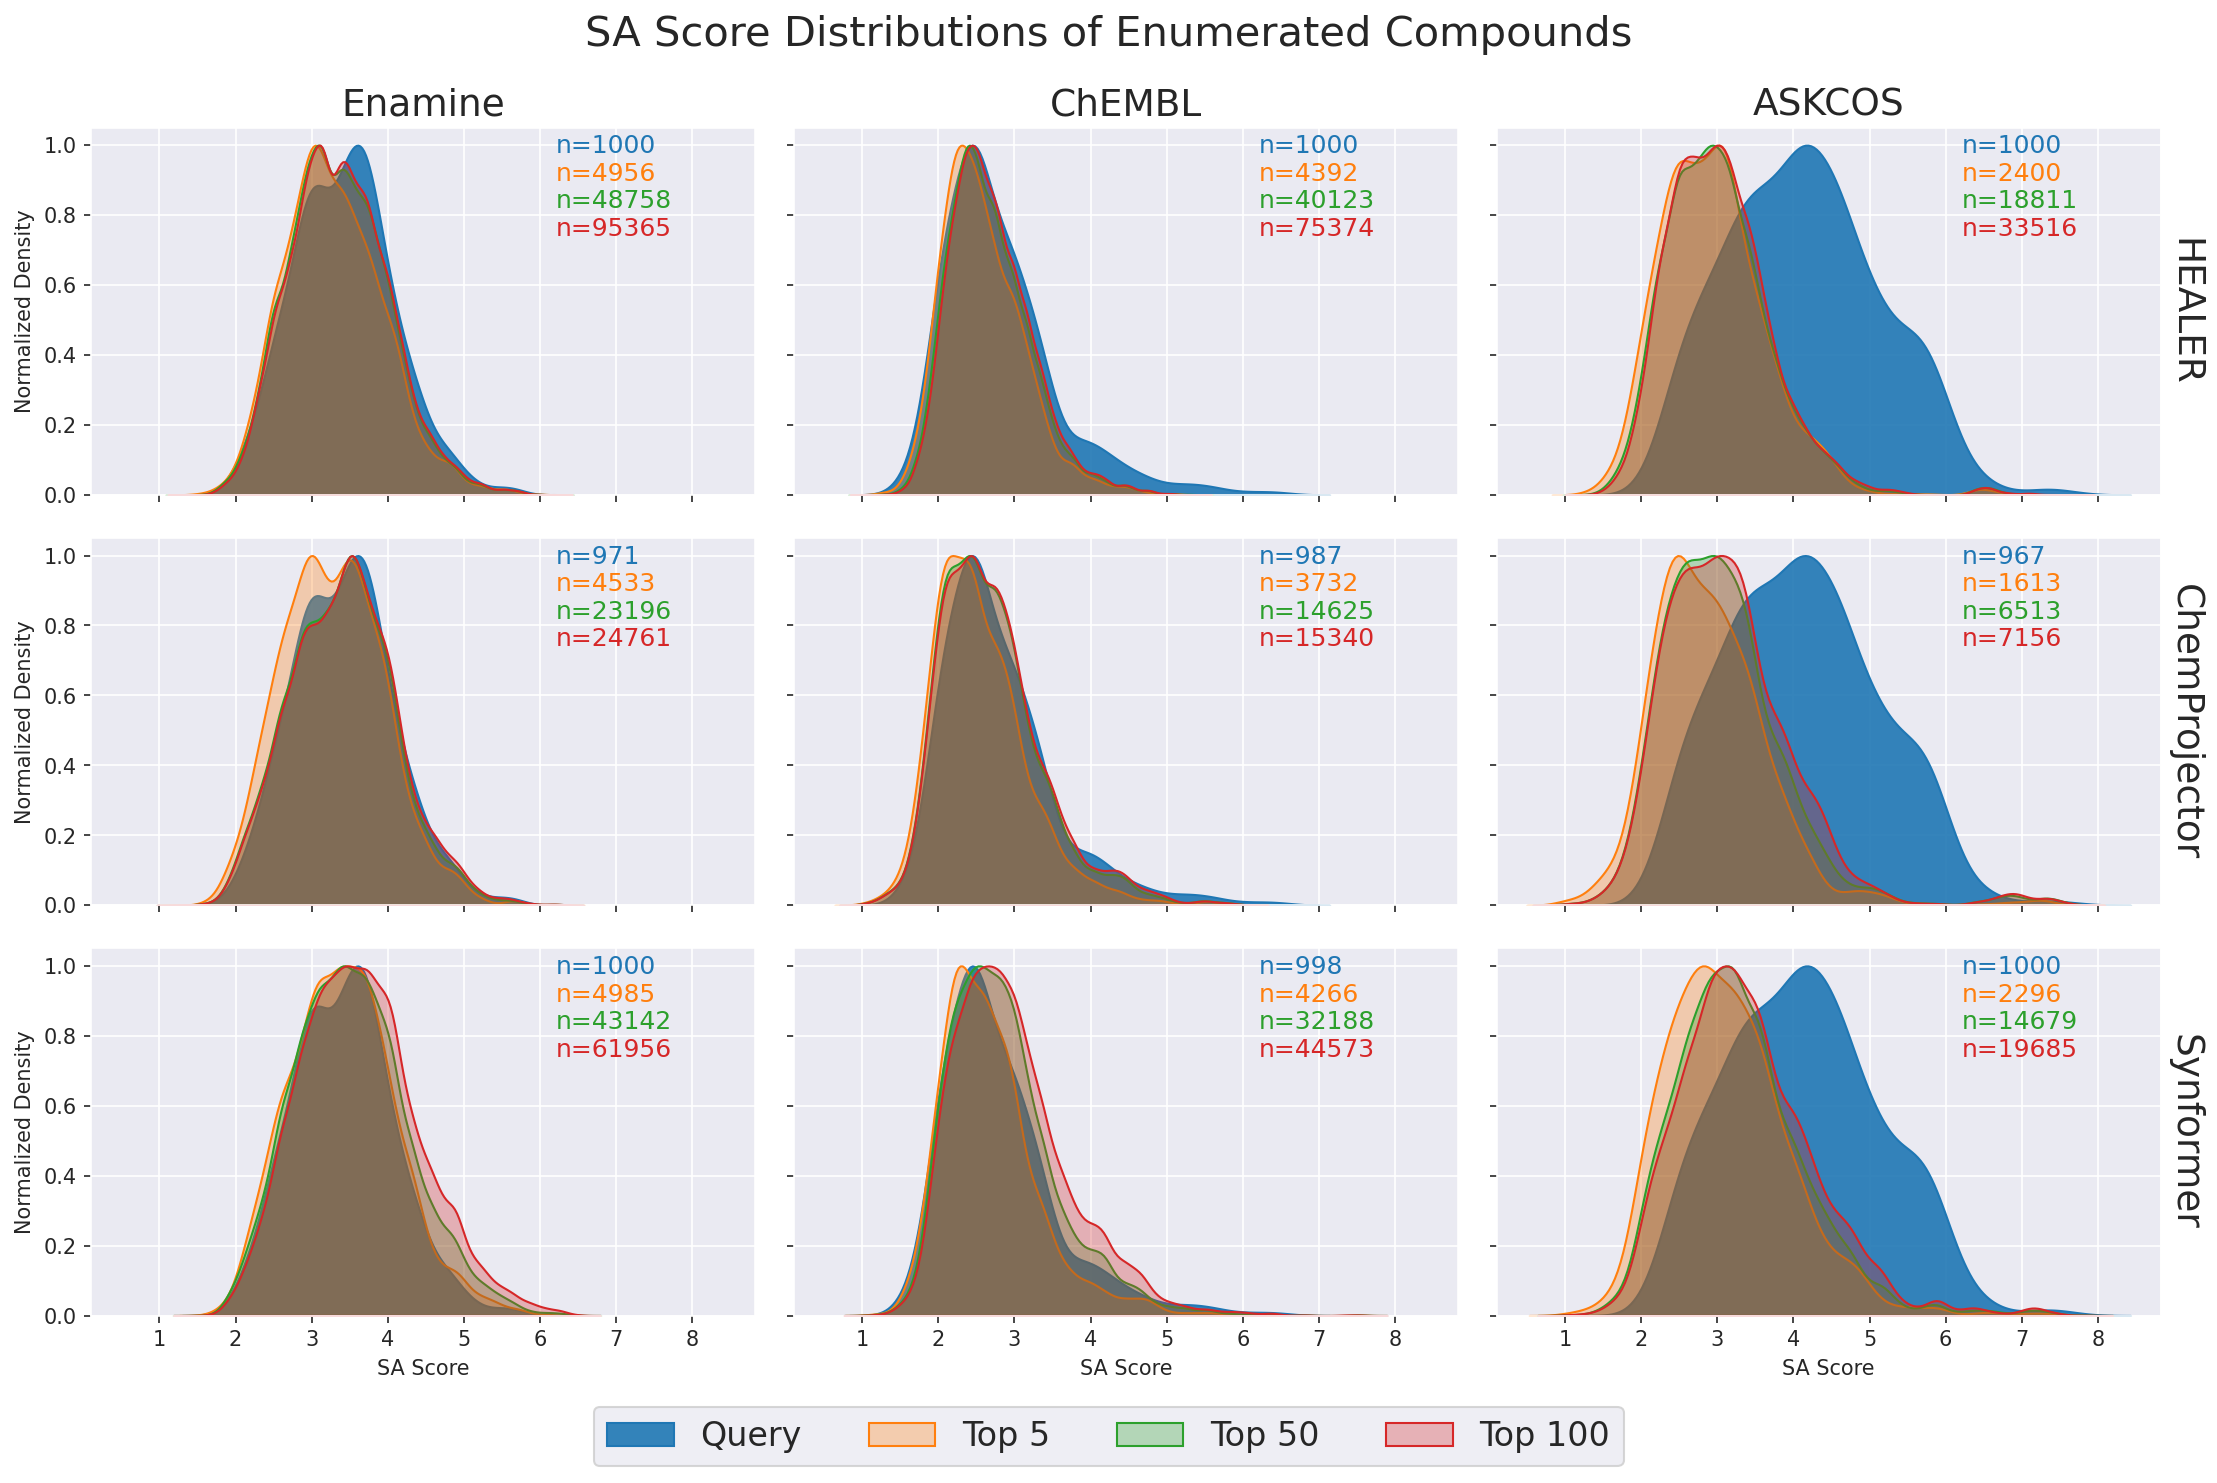

In [7]:
## plot SA score distributions
# helper plot functions
def kdeplot(data, line_number, **kwargs):
    ax = sns.kdeplot(data, **kwargs)
    if 'fill' in kwargs.keys() and kwargs['fill']==True:
        path = ax.collections[line_number].get_paths()
        ys = min_max_normalize(path[0].vertices[:, 1])
        path[0].vertices[:, 1] = ys
    else:
        line = ax.lines[line_number]
        line.set_ydata(min_max_normalize(line.get_ydata()))
    ax.set_ylim(0, 1.05)       
    ax.autoscale_view()
    return ax

def plot_distributions(arrays, labels, ax, metric_name, normalize_y=True, title=None, sec_ylabel=None, annotate_n=True):
    if normalize_y:
        for i, (arr, label) in enumerate(zip(arrays, labels)):
            alpha = 0.3 if label != 'Query' else 0.9
            kdeplot(arr, i, color=f'C{i}', label=label, alpha=alpha, fill=True, ax=ax, )
    else:
        for i, (arr, label) in enumerate(zip(arrays, labels)):
            alpha = 0.3 if label != 'Query' else 0.9
            sns.kdeplot(arr, color=f'C{i}', label=label, alpha=alpha, fill=True, ax=ax)
    # annotate number of samples for each distribution
    if annotate_n:
        for i, (arr, label) in enumerate(zip(arrays, labels)):
            ax.annotate(f'n={len(arr)}', xy=(0.70, 0.95-(i*0.075)), xycoords='axes fraction', fontsize=12,
                        ha='left', va='center', color=f'C{i}')
    ax.set_title(f'{title}', fontsize=18)
    ax.set_xlabel(metric_name)
    ax.set_ylabel('Normalized Density')
    if sec_ylabel:
        secax = ax.secondary_yaxis('right')
        secax.set_ylabel(sec_ylabel, fontsize=18, rotation=270, labelpad=20)
        secax.set_yticks([]); secax.set_yticklabels([])
    ax.legend()

# plotting
with sns.axes_style("darkgrid", rc={"xtick.bottom": True, "ytick.left": True}):
    # Collect SA scrore arrays for each subset
    sa_score_arrays = []
    subsets = [
        healer_enamine_subset, healer_chembl_subset, healer_askcos_subset,
        chemprojector_enamine_subset, chemprojector_chembl_subset, chemprojector_askcos_subset,
        synformer_enamine_subset, synformer_chembl_subset, synformer_askcos_subset
    ]
    for subset in subsets:
        arrs = [get_top_n_subset(subset, n=0)['SA_score'].to_numpy()]
        for top_n in [5, 50, 100]:
            top_n_subset = get_top_n_subset(subset, n=top_n)
            arrs.append(top_n_subset[top_n_subset['ID'] != 'HEAL_000000']['SA_score'].to_numpy())
        sa_score_arrays.append(arrs)

    # Define labels and titles for the plots
    distribution_labels = [
        'Query', 'Top 5', 'Top 50', 'Top 100',
    ]
    titles = ['Enamine', 'ChEMBL', 'ASKCOS'] + [''] * 6
    row_titles = ['', '', 'HEALER'] + ['', '', 'ChemProjector'] + ['', '', 'Synformer']

    # Create subplots
    fig, axes = plt.subplots(3, 3, figsize=(15, 10), dpi=150, sharex=True, sharey='all')
    axes = axes.flatten()
    for i, (df, title, r_title) in enumerate(zip(sa_score_arrays, titles, row_titles)):
        ax = axes[i]
        plot_distributions(df, distribution_labels, ax, 'SA Score',
                           normalize_y=True, title=title, sec_ylabel=r_title, annotate_n=True)
        ax.legend_.remove()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
            loc='lower center',
            ncol=len(labels),
            frameon=True,
            fontsize=16,)
    fig.suptitle('SA Score Distributions of Enumerated Compounds', fontsize=20)
    fig.tight_layout(pad=1.5, rect=[0, 0.05, 1, 1])


In [8]:
# test signigicance of differences between top-n and query distributions
# Alternative Hypothesis: The SA score of the enumerated compounds is significantly lower than the query compounds.
# Null Hypothesis: The SA score of the enumerated compounds is not significantly lower than the query compounds.
from scipy.stats import ttest_ind
from itertools import product

def significance_test(data_arrays, distribution_labels):
    query_vals = data_arrays[0]
    for i in range(1, len(data_arrays)):
        # T-test
        t_stat, t_pval = ttest_ind(query_vals, data_arrays[i], alternative='greater')
        sign_level = 'ns' if t_pval > 0.05 else '*' if 0.01 < t_pval <= 0.05 else '**' if 0.001 < t_pval <= 0.01 else '***'
        print(f"T-test: {distribution_labels[i]} vs Query: statistic={t_stat:.4f}, p-value={t_pval:.4f} ({sign_level})")

labels = list(product(
    ['HEALER', 'ChemProjector', 'Synformer'],
    ['Enamine', 'ChEMBL', 'ASKCOS'],
))
for i in range(len(labels)):
    print(f"Significance results for {labels[i][0]} on {labels[i][1]}")
    significance_test(sa_score_arrays[i], distribution_labels)
    print()


Significance results for HEALER on Enamine
T-test: Top 5 vs Query: statistic=5.9511, p-value=0.0000 (***)
T-test: Top 50 vs Query: statistic=3.6636, p-value=0.0001 (***)
T-test: Top 100 vs Query: statistic=2.7899, p-value=0.0026 (**)

Significance results for HEALER on ChEMBL
T-test: Top 5 vs Query: statistic=10.9798, p-value=0.0000 (***)
T-test: Top 50 vs Query: statistic=8.1287, p-value=0.0000 (***)
T-test: Top 100 vs Query: statistic=6.4523, p-value=0.0000 (***)

Significance results for HEALER on ASKCOS
T-test: Top 5 vs Query: statistic=40.6861, p-value=0.0000 (***)
T-test: Top 50 vs Query: statistic=49.8508, p-value=0.0000 (***)
T-test: Top 100 vs Query: statistic=49.1240, p-value=0.0000 (***)

Significance results for ChemProjector on Enamine
T-test: Top 5 vs Query: statistic=6.1585, p-value=0.0000 (***)
T-test: Top 50 vs Query: statistic=1.4017, p-value=0.0805 (ns)
T-test: Top 100 vs Query: statistic=0.1752, p-value=0.4305 (ns)

Significance results for ChemProjector on ChEMBL
T

# Drug-Likeliness Analysis

In [ ]:
## Helper functions for displaying SVG molecules in Jupyter notebooks
def display_svg_mol(svg_mol: str):
    '''
        Utility function to display get_svg_mol/get_svg_mol_with_bbs output
        in a Jupyter notebook.

        Args:
            svg_mol: str, SVG image of the molecule.
    '''
    svg_mol = svg_mol.replace('data:image/svg+xml;base64,', '')
    svg_mol = base64.b64decode(svg_mol)
    display(SVG(svg_mol))

def display_svg_grid(svg_mols, ncols=3, justify_items='center'):
    """
        Display a list of IPython.core.display.SVG objects in a CSS grid.
    
        Args: 
            svg_mols: list of svg_mols
            ncols: int, number of columns in the grid.
            justify_items: str, CSS justify-items property for grid cells 
                (e.g. 'center', 'start').
    """
    container_style = (
        f"display: grid;"
        f"grid-template-columns: repeat({ncols}, min-content);"
        f"row-gap: 0; column-gap: 0;"
        f"gap: 0;"               # catch-all
        f"margin: 0; padding: 0;"
        f"line-height: 0;"       # avoid any inline-whitespace
    )
    
    html = [f'<div style="{container_style}">']
    for svg_mol in svg_mols:
        svg_mol = svg_mol.replace('data:image/svg+xml;base64,', '')
        svg_mol = base64.b64decode(svg_mol)
        svg = SVG(svg_mol)
        if getattr(svg, "data", None):
            svg_text = svg.data
        
        svg_block = re.sub(
            r"<svg(\s|>)",
            r'<svg style="display:block;margin:0;padding:0;"\1',
            svg_text,
            count=1
        )
        html.append(svg_block)
    html.append("</div>")
    
    display(HTML("".join(html)))

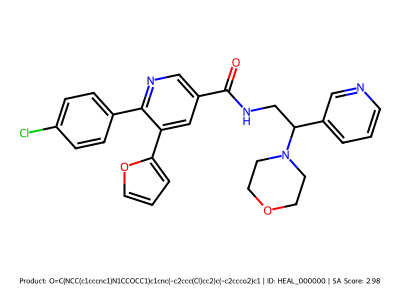

In [150]:
tmp_mol = Chem.MolFromSmiles(tmp.Product.values[0])
from rdkit.Chem import Draw
Draw.MolsToGridImage([tmp_mol], molsPerRow=1, useSVG=True, subImgSize=(400, 300), 
                     legends=[f"Product: {tmp.Product.values[0]} | ID: {tmp.ID.values[0]} | "
                              f"SA Score: {tmp.SA_score.values[0]:.2f}"])

In [ ]:
n_mols = 100
svgs = []
for i in range(1, n_mols+1):
    if tmp.cns_mpo_score.values[i] < 5.0:
        continue
    svg = utils.get_svg_mol_with_bbs(
        tmp.Product.values[i],
        tmp.BB1.values[i],
        tmp.BB2.values[i],
        legend=f"Tanimoto: {tmp.Similarity_to_query.values[i]}; " 
                f"Stoplight: {tmp.stoplight_colors.values[i]}\n"
                f"CNS-MPO: {round(tmp.cns_mpo_score.values[i], 2)}; "
                f"QED: {round(tmp.qed.values[i], 2)}"
    )
    svgs.append(svg)

display_svg_grid(svgs, ncols=3)


: 

In [ ]:
def plot_drug_likeliness_profiles(input_file=None, data=None):
    '''
        Plot the drug-likeliness profiles of enumerated molecules.

        Args:
            input_file (str): The file containing the enumerated molecules with properties.
                If provided, this file will be read to extract the data.
            data (pd.DataFrame): If provided, this DataFrame will be used directly instead of reading from a file.

        Returns:
            None: Displays the plot.
    '''
    if data is None:
        data = pd.read_csv(input_file)
    data = data.dropna(subset=['cns_mpo_score', 'qed', 'stoplight_colors']).reset_index(drop=True)
    data['plot_color'] = data['stoplight_colors'].apply(lambda x: 'gold' if x == 'yellow' else x)
    query_molecule = data[data['ID'] == 'HEAL_000000'].reset_index(drop=True)
    data = data[data['ID'] != 'HEAL_000000']
    n = len(data)

    # plot the enumeration profiles
    fig = plt.figure(figsize=(10, 8), dpi=150)
    plt.rcParams.update({'font.size': 16})
    stoplight_cmap = mpl.colors.ListedColormap(['red', 'gold', 'green'])
    stoplight_norm = mpl.colors.BoundaryNorm(np.linspace(0, 3, 4), stoplight_cmap.N)

    ax0 = fig.add_subplot(111)
    y_jitter = np.random.normal(0, 0.02, (n,)) * np.array([0] + [1] * (n - 1))
    ax0.scatter(data['qed'], data['cns_mpo_score']+y_jitter, 
                c=data['plot_color'], s=80, alpha=0.5, label='Enumerated Molecules')
    ax0.scatter(query_molecule['qed'], query_molecule['cns_mpo_score'], edgecolors='blue', 
                facecolors=query_molecule['stoplight_colors'], s=750, label='Query Molecules',
                marker=mpl.markers.MarkerStyle(marker='*', fillstyle='full'), linewidths=2.5
                )
    # add colorbar for stoplight color
    cbar = plt.colorbar(mpl.cm.ScalarMappable(cmap=stoplight_cmap, norm=stoplight_norm), ax=ax0)
    cbar.set_ticks([0.5, 1.5, 2.5])
    cbar.set_ticklabels(['Bad', 'Average', 'Good'], fontsize=10)
    cbar.set_label('Stoplight\nScore', loc='top', rotation=0, labelpad=14, fontsize=12)
    ax0.set_xlabel('QED', fontsize=12); ax0.set_ylabel('CNS MPO Score', fontsize=12)
    ax0.set_title('Drug-likeliness Profiles', fontsize=14)
    ax0.legend(labels=['Enumerated Molecules', 'Query Molecule'],
               handles=[mpl.lines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10),
                        mpl.lines.Line2D([], [], color='blue', marker='*', linestyle='None', fillstyle='none', markersize=20)],
               fontsize=12) 
    plt.show()

plot_drug_likeliness_profiles(data=tmp)


# Computational Performance


/tmp/ipykernel_18338/3784411811.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_18338/3784411811.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right')


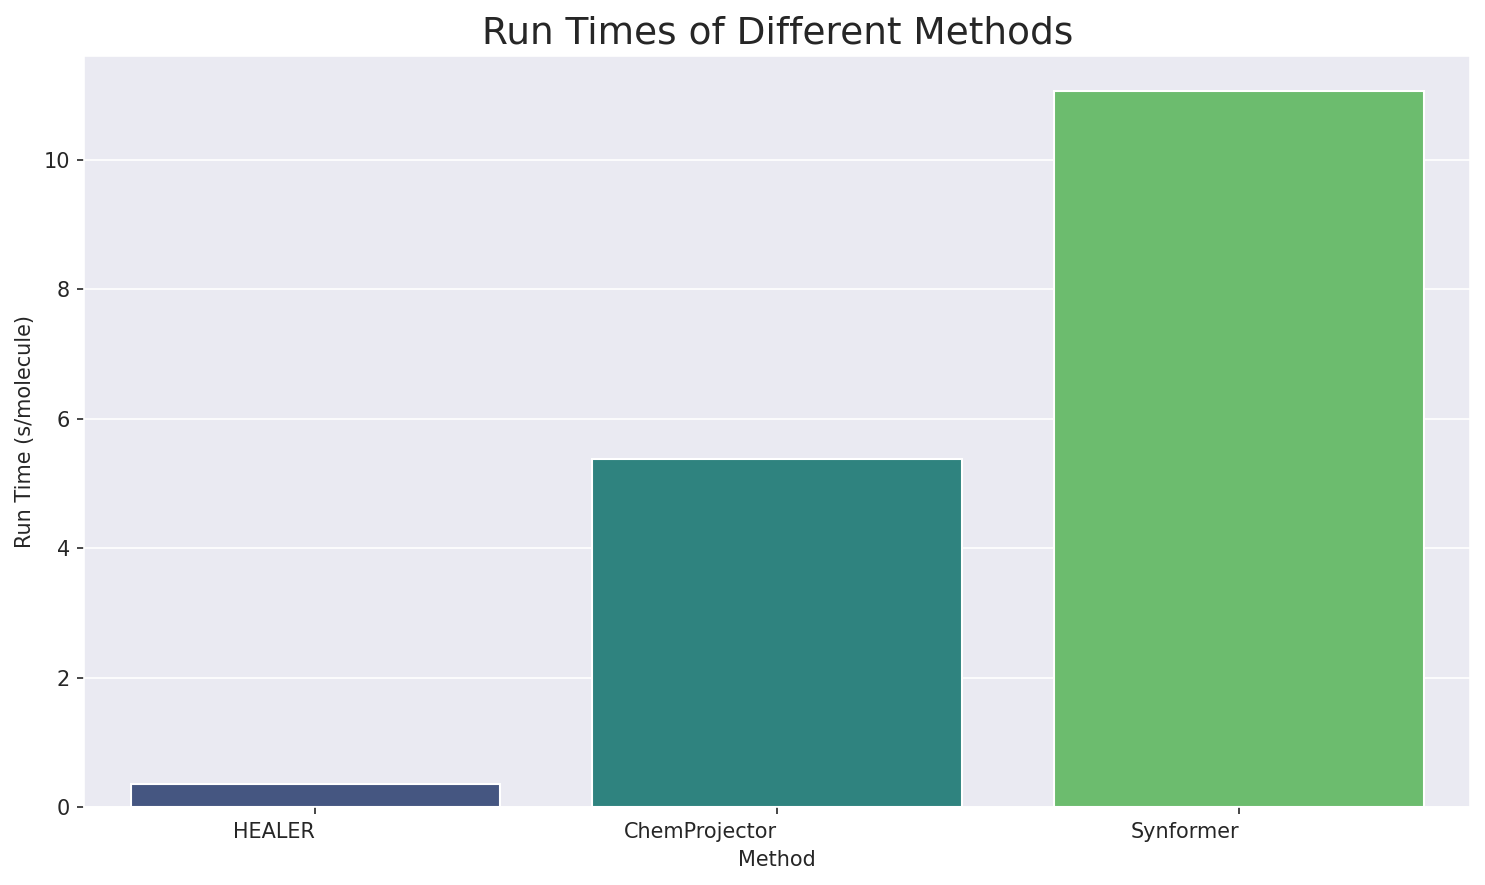

In [7]:
run_times = { # in seconds per single enumeration
    'HEALER': [0.35],
    'ChemProjector': [5.38],
    'Synformer': [11.06],
}
def plot_run_times(run_times, labels, ax):
    sns.barplot(
        x=labels,
        y=[np.mean(times) for times in run_times.values()],
        ax=ax,
        palette='viridis',
    )
    ax.set_ylabel('Run Time (s/molecule)')
    
# plotting run times
with sns.axes_style("darkgrid", rc={"xtick.bottom": True, "ytick.left": True}):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    plot_run_times(run_times, list(run_times.keys()), ax)
    ax.set_title('Run Times of Different Methods', fontsize=18)
    ax.set_xlabel('Method')
    ax.set_xticklabels(ax.get_xticklabels(), ha='right')
    plt.tight_layout()
    plt.show()
